<a href="https://colab.research.google.com/github/bforoura/ML26/blob/main/Module0_Python/Notebook_4_First_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **First Machine Learning Model (Linear Regression)**

* **Linear regression** is a fundamental statistical and machine learning technique used to model the relationship between a **dependent variable** (the outcome you want to predict) and one or more **independent variables** (the inputs).


* By fitting a straight line—known as the line of best fit—through the data points, it estimates how changes in the inputs affect the output.

* This allows you to predict future values or understand trends, such as estimating a house's price based on its square footage.

<br>

**Example:**
The figure below is  a sample linear regression graph showing the relationship between house square footage and price.
  * The **independent variable (square footage)** is plotted on the x-axis
  * The **dependent variable (price)** is on the y-axis.
  * The **red line represents the best-fit line** calculated through the data points, which allows us to predict the house price for a given square footage.
  * For instance, according to this model, a 2,500 sq ft house would be predicted to cost roughly $325,000.

<br>

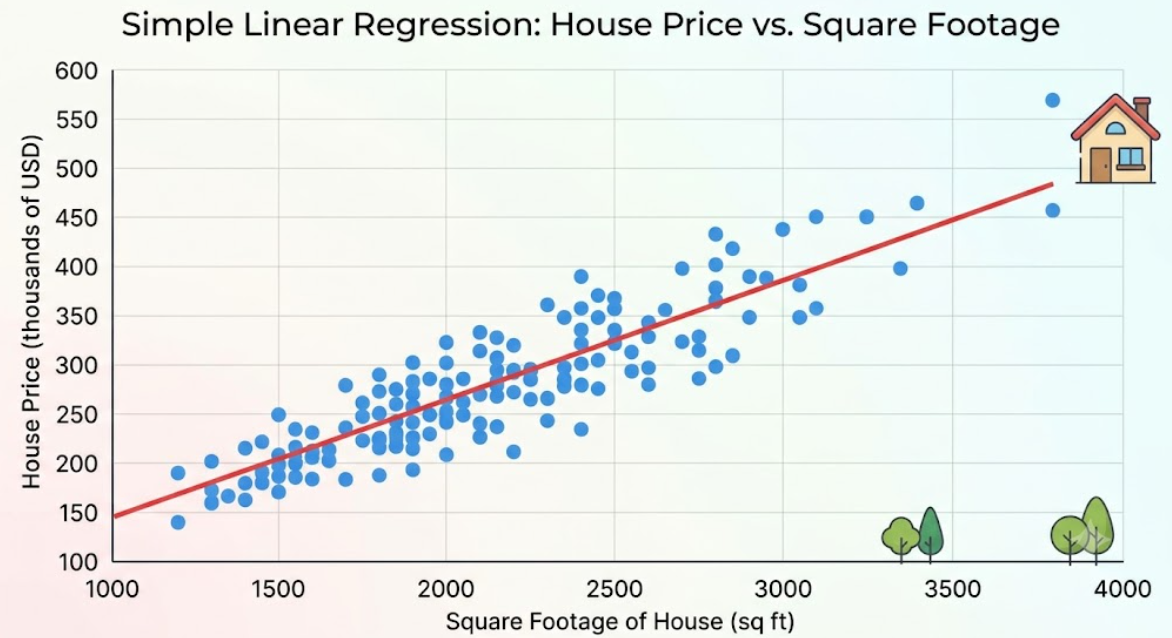

# **The Needed Libraries**

* The following code cell contains the fundamental building blocks needed to build, train, and evaluate a machine learning model using Python.

* They import specific tools from two of the most popular libraries in data science: **Pandas** and **scikit-learn (sklearn)**.

<br><br>

**import pandas as pd**
 * Discussed previously


<br><br>

**from sklearn.model_selection import train_test_split**

* Imports a function that splits your dataset into two parts.

* To properly test a machine learning model, you cannot use the exact same data it learned from.

* This function splits your data into:

  * **Training set**: The data the model uses to learn the patterns (usually 70–80% of the data).

  * **Testing set**: The "final exam" data used to see how accurate the model is on unseen data (usually 20–30%).


<br><br>


**from sklearn.linear_model import LinearRegression**

* Imports the actual Linear Regression algorithm.

* This is the math engine that will look at your training data and draw that "**line of best fit**" we discussed earlier.

* Once imported, you can train it on your data using a single command (like .fit()).


<br><br>

**from sklearn.metrics import mean_squared_error**

* Imports an evaluation metric to **measure model performance**.

* **Mean Squared Error (MSE)** calculates how far off your model's predictions are from the actual, true values.

* It squares the errors so that larger mistakes are penalized more heavily. A lower MSE means your model made highly accurate predictions.


<br><br>

**ML Workflow**
* In a real script, our workflow goes directly through these imports:

  * We load data with pd.
  * We split it with train_test_split.
  * We train your LinearRegression model on the training data.
  * The score indicates how well it did on the test data using **mean_squared_error**.


  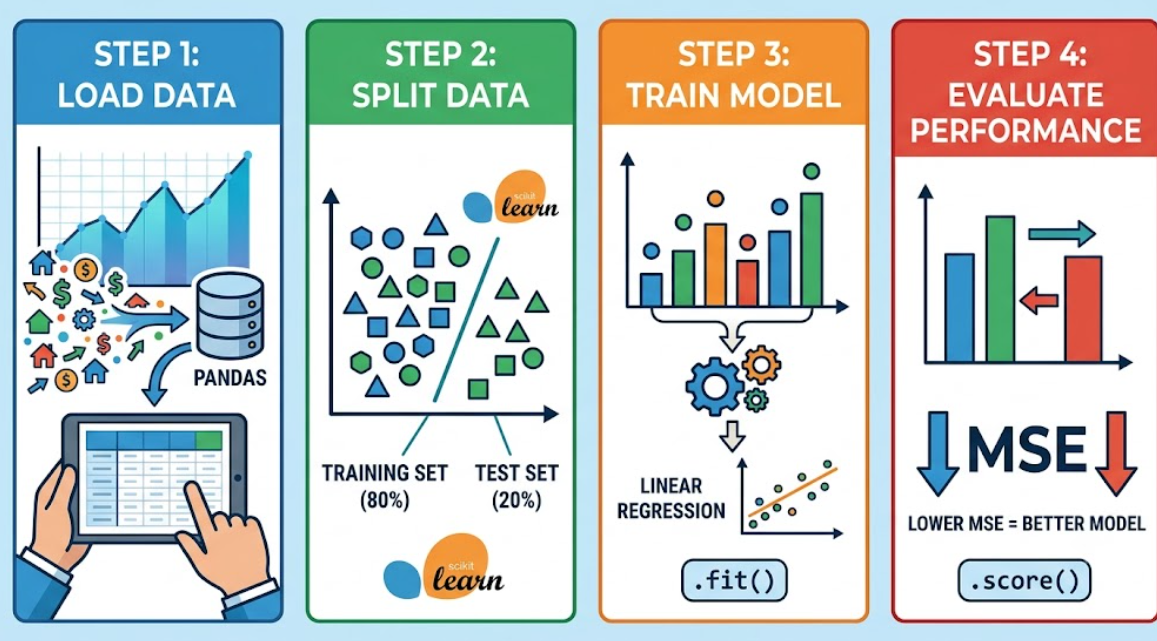

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# **California Housing Dataset**

* This part examines a small slice of a the entire dataset of 20,640 rows.

* The first row contains the column names, and the rows below it contain the actual data points.

* Here is what each column (feature) means and how they are used:

  * **MedInc (Median Income)**: The median income for households in a specific block/neighborhood (usually scaled, e.g., tens of thousands of dollars). This is often the strongest predictor of house value.

  * **HouseAge**: The median age of the houses in that block.

  * **AveRooms**: The average number of rooms per household.

  * **AveBedrms**: The average number of bedrooms per household.

  * **Population**: The total number of people residing within that block.

  * **AveOccup**: The average number of household members (occupancy).

  * **Latitude & Longitude**: The exact geographical coordinates of the block. Location matters heavily in real estate!

  * **target**: This is the **dependent variable** (the output column y we discussed earlier). In this specific dataset, it represents the median house value for that block, typically expressed in hundreds of thousands of dollars (e.g., 4.526 means $452,600).

In [3]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X = df.drop('target', axis=1)
y = df['target']

# **Data Preparation**


* This step is where we prepare the data by separating it into **features** (the information our model uses to learn) and the **target** (the specific outcome you want the model to predict).


* Think of it like studying for a test: you need to separate the study questions from the answer key so you can practice properly.


<br><br>

**X = df.drop('target', axis=1)**
* This creates the feature dataset, conventionally named with a capital X (because it represents a 2D matrix or table of data).

* It takes the  entire DataFrame (df) and drops the column named 'target'. The **axis=1** tells Pandas to drop a column rather than a row.

* **X** now contains all of your independent variables—the inputs like square footage, number of bedrooms, and neighborhood quality—without the actual price.

<br><br>

**y = df['target']**

* This creates the target variable, conventionally named with a lowercase y (because it represents a 1D vector or single column of data).

* It grabs only the column named 'target' from the DataFrame.

* **y** contains the dependent variable—the exact values you want the model to learn how to predict (like the actual house price).


<br>

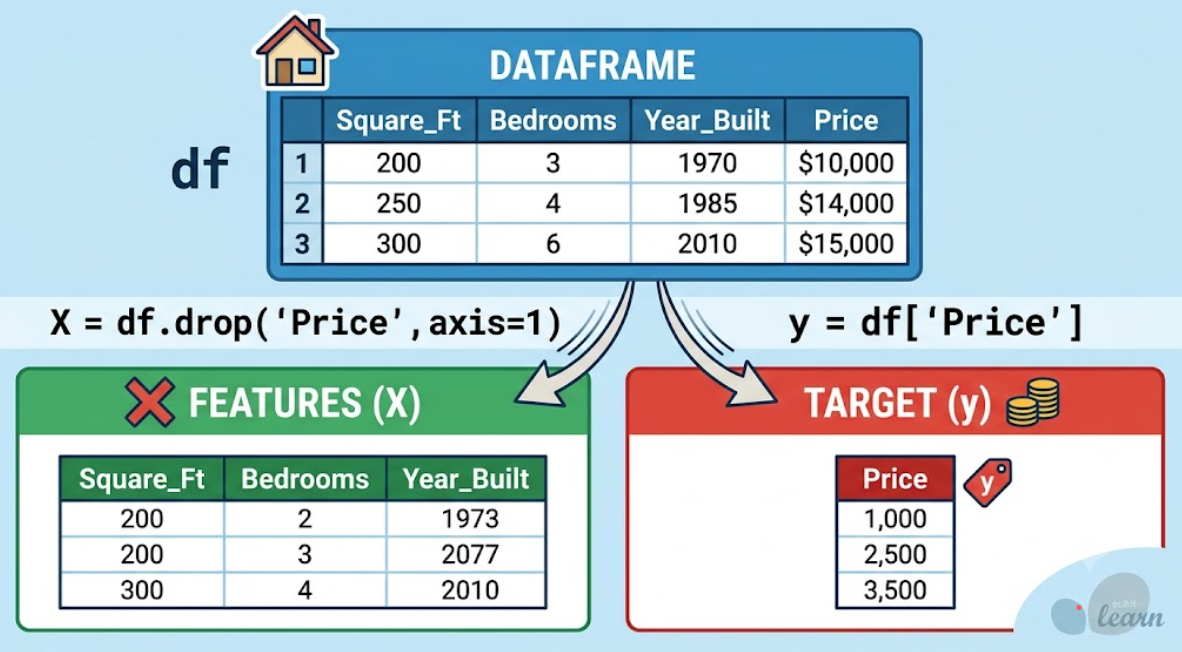

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Training/Testing Datasets**


**1. The Four Outputs (The Left Side)**
* The function returns four distinct subsets of our data, which we catch in these variables:

* **X_train**: The input features our model will study (approx. 16,512 rows).

* **X_test**: The input features we hide from the model to use for testing later (approx. 4,128 rows).

* **y_train**: The correct target answers (house prices) that correspond to X_train.

* **y_test**: The correct target answers that correspond to X_test so we can grade our model's final predictions.


<br>

**2. The Inputs and Settings (The Right Side)**

* **X, y**: These are the original, complete datasets we created in the previous step.

* **test_size=0.2**: This tells the function we want to allocate exactly 20% of our 20,640 rows to the test set, leaving the remaining 80% for the training set.

* **random_state=42**: Before splitting, the function shuffles our rows so the data is completely mixed. Setting this to 42 (or any fixed number) ensures the shuffle happens exactly the same way every time we run the code. This makes our experiments reproducible so we always get the same results.


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Creating the Model**


**model = LinearRegression()**
* This initializes our machine learning model.

* Think of this as hiring an empty-brained mathematician.

* At this exact moment, the model exists, but it knows absolutely nothing about California housing prices, square footage, or neighborhood incomes.

* It is just a blank blueprint containing the mathematical formulas for linear regression, waiting for data.


<br><br>

**model.fit(X_train, y_train)**

* This is the actual "training" or "learning" step.

* The **.fit() **command tells the model to look at our training features (X_train) and the corresponding correct answers (y_train) to figure out the math.

* The algorithm analyzes all 16,512 rows of our training data simultaneously.

* It calculates the optimal weights (**coefficients**) for every single feature—like how much weight to give to MedInc versus HouseAge—to draw the multidimensional line of best fit.

* Example:
<br>

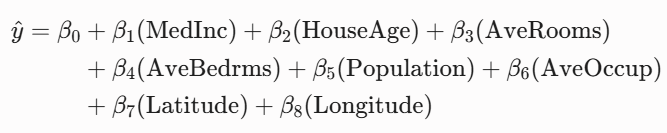

In [7]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print('MSE:', mse)

MSE: 0.5558915986952444


# **Model Evaluation**


* These final lines of code are where we test our trained model to see how smart it actually is.

* This is the "final exam" phase of our machine learning workflow.

<br><br>

**1. predictions = model.predict(X_test)**
* We pass the unseen test features (X_test) into our trained model and ask it to guess the house prices.

* Notice that we only give the model X_test (the features like income and location). We do not show it the correct answers (y_test).

* The model uses its learned equation to generate a brand new list of predicted prices, which we store in the variable predictions.


<br>

**2. mse = mean_squared_error(y_test, predictions)**

* This is where we grade the exam.
* This function compares the model's guesses (predictions) against the actual, true house prices (y_test) that we hid away earlier.

* For every single house in our test set, the function calculates the error (the distance between the true value and the predicted value), squares that error so negative differences don't cancel out positive ones, and then takes the average of all those squared errors.

<br>

**3. print('MSE:', mse)**

* This displays the final score on our screen.

* Because it is a measure of error, we want this number to be as close to zero as possible.

* A lower MSE means our regression line sits very close to our real data points, proving that our model is highly accurate at predicting California housing prices!

<br>
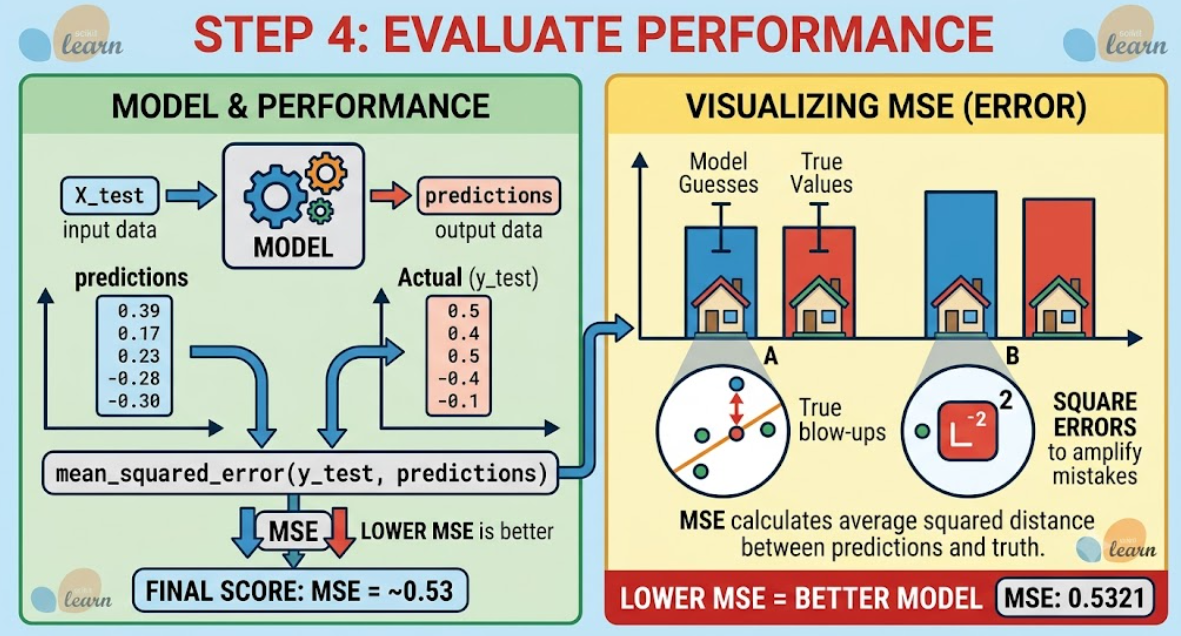
<br>